In [1]:
try:
    import math as my
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import pandas as pd
    print(f'Pandas {pd.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import numpy as np
    print(f'Numpy {np.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import xarray as xr
    print(f'Xarray {xr.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import matplotlib as mat
    import matplotlib.pyplot as plt
    print(f'Matplotlib {mat.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try:
    import calendar as cally
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')    

try:
    import time as time
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try:
    import scipy as sp
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    from datetime import timedelta
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import regionmask as remy
    print(f'Regionmask {remy.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
import os
import sys

Pandas 2.3.0 loaded successfully
Numpy 2.2.6 loaded successfully
Xarray 2025.7.0 loaded successfully
Matplotlib 3.10.3 loaded successfully
Regionmask 0.13.0 loaded successfully


In [3]:
#SUPPORT CELL
model = input(f'Pray tell which model this is? ')
mode = input(f'And which series are we in? ')
global T, RH, W, RA , droughtlength, dufflength, month_call, D1, filepath1, filepath2

######MODELS TO RUN#####
## CESM2
## BCC 
## IPSL
## GFDL

#winter = 152 steps
#summer = 214 steps

# 1095 = 19840101
# 5908 = 19970310
# 6035 = 19970715
# 6184 = 19971210
# 8395 = 20040101

filepath1 = f'/mnt/nrdstor/dixon/mudby97/FWI_test/dap.ceda.ac.uk/badc/evoflood/data/Downscaled_CMIP6_Climate_Data/tasmax/Historical/Global_tasmax_Downscaled_{model}_1981-2014_compressed.nc'
filepath2 = f'/mnt/nrdstor/dixon/mudby97/FWI_test/dap.ceda.ac.uk/badc/evoflood/data/Downscaled_CMIP6_Climate_Data/pr/Historical/Global_pr_Downscaled_{model}_1981-2014_compressed.nc'

Pray tell which model this is? CESM2
And which series are we in? Historical


In [4]:
yl =  slice(40,43)  # 40.7 FOR LINCOLN OR slice(40,43) FOR NEBRASKA
xl = slice(256, 265) # 263.55 FOR LINCOLN OR slice(256, 265) FOR NEBRASKA
timestamp = range(1095,12045)
tasfile = xr.open_dataset(filepath1)
prfile = xr.open_dataset(filepath2)

#HISTORICAL TIMESTAMP IS range(1095,12045)
#FUTURE TIMESTAMP IS range(range(4014,15330))

##FOLLOWING ISOLATES NETCDF DATA TO NEBRASKA AND SELECTED TIMESTAMP
tas = tasfile['tasmax'].sel(
    time=tasfile['time'][timestamp],
    lat=yl,
    lon=xl)
pr = prfile['pr'].sel(
    time=prfile['time'][timestamp],
    lat=yl, #slice(40, 43),   # 40-43
    lon=xl) #slice(256, 265)) # 256-265

##CONVERTING FROM CMIP6 VARS TO CFWI VARS

T =  tas 
RA = pr

try:
    print('All dependencies loaded. Proceeding with index.')
except ValueError as ve:
    print(f'{ve}')
except KeyError as ke:
    print(f'{ke}')
except AttributeError as aa:
    print(f'{aa}')
finally:
    print:('Something else went wrong. Good luck.')

print(f'{len(timestamp)}')
print(f"{tas.coords}")

All dependencies loaded. Proceeding with index.
10950
Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
  * time     (time) datetime64[ns] 88kB 1984-01-01 1984-01-02 ... 2013-12-31


In [5]:
#DROUGHT CODE FOR STATE PLOTTING 16JUL ITERATION - FOLLOWS CFWI 1985 DOCUMENTATION 

def monthcall(t, timestamp):
        time_val = t['time'][timestamp].values
        try:
            month_call = time_val.dt.strftime("%#m") #pd.to_datetime((time_val)).strftime('%#m')
            month = month_call
            return month
        except Exception as e:
            month_call = 0x7
            month = month_call
            return month

def drought_code(t, precip, D0, timestamp):  
    # t = internal temperature vars, precip = precip value in place for RA, droughtlength = dictionary call daylength for DC, month_call = figures month from the tas.nc
        e = my.e
        droughtlength = {
        0x1: -1.6, #JAN
        0x2: -1.6, #FEB
        0x3: -1.6, #MAR
        0x4: 0.9, #APR
        0x5: 3.8, #MAY
        0x6: 5.8, #JUN
        0x7: 6.4, #JUL
        0x8: 5.0, #AUG
        0x9: 2.4, #SEP
        10: 0.4, #OCT
        11: -1.4, #NOV
        12: -1.6, #DEC
    }
        
        rdc = xr.full_like(t, fill_value=np.nan) #THIS IS THE EMPTY ARRAY FOR OUR FINDINGS TO PRINT TO 
        r0 = precip
        start_time = time.perf_counter()  

        def calc_dc(t, r0, D0, timestamp): #STEP THREE- THE ACTUAL DC EQUATION    
                Lf_func = monthcall(t, timestamp)
                Lf = droughtlength[Lf_func]
                t_val = t.values[timestamp, lat_idx, long_idx]
                
                #print(r0)
                if r0 >= 2.8:
                        #print(f'You triggered the precip func with a value of {r0} here') UNCOMMENT FOR DEBUGGING
                    rd = (0.83 * r0)-1.27
                    Q0 = (800 * (e)**(-D0/400))
                #FOLLOWING CONVERTS Qr TO Dr READING FROM Q0
                    Qr = Q0 + (3.937 * rd)
                    Dr = (400 * np.log(800/Qr))
                    if Dr < 0: # MOISTURE EQUIVALANCY CANNOT GO NEGATIVE
                        Dr = 0 
                    else: pass
                    D0 = Dr
                else: pass 
                if t_val < -2.8: #CANNOT USE TEMPERATURES LOWER THAN -2.8C
                    t_val = -2.8
                else: pass    
                V = 0.36 * (t_val + 2.8) + Lf    
                if V < 0: #V CALC CANNOT BE NEGATIVE 
                    V = 0
                else:
                        #print(f'V VALUE AT STEP {i} is {V}') UNCOMMENT FOR DEBUGGING
                    pass       
                DC = D0 + (0.5 * V)
                if DC > 2000:
                    DC = 2000 #CANNOT HAVE HIGHER THAN 2000 FROM WHAT I CAN TELL
                else:
                    pass
                    #print(f'THE TEST DC AT STEP {i} is {DC}') UNCOMMENT FOR DEBUGGING
                D1 = DC
                return DC
                return D1

        for lat_idx in range(t.shape[1]):
                for long_idx in range(t.shape[2]):
                    for time_idx in range(t.shape[0]):
                        r0_val = precip.values[time_idx, lat_idx, long_idx]
                        FDC = calc_dc(t, r0_val, D0, time_idx)
                        rdc.values[time_idx, lat_idx, long_idx] = FDC
                        D0 = FDC
                check_time = timedelta(seconds=time.perf_counter() - start_time)
                print(f"Checkpoint: {lat_idx} at {check_time}")
        return rdc
        loop_time = timedelta(seconds=time.perf_counter() - start_time)
        print(f"This took us about {loop_time}")
        
print(f'Running the DC Code for {model}')      
testrun = drought_code(T, RA, 15, timestamp)
print(testrun)

Running the DC Code for CESM2
Checkpoint: 0 at 0:04:52.130438
Checkpoint: 1 at 0:06:30.953560
Checkpoint: 2 at 0:08:09.496818
Checkpoint: 3 at 0:09:48.266634
Checkpoint: 4 at 0:11:26.802297
Checkpoint: 5 at 0:13:05.627827
Checkpoint: 6 at 0:14:44.563521
Checkpoint: 7 at 0:16:23.275102
Checkpoint: 8 at 0:18:01.957493
Checkpoint: 9 at 0:19:40.512219
Checkpoint: 10 at 0:21:19.263805
Checkpoint: 11 at 0:22:57.752319
<xarray.DataArray 'tasmax' (time: 10950, lat: 12, lon: 36)> Size: 19MB
array([[[  19.113075, 1016.848   ,  985.48834 , ...,  593.98206 ,
          612.27094 ,  615.8852  ],
        [ 653.7531  ,  953.80414 ,  909.1283  , ...,  613.2086  ,
          632.9141  ,  625.0637  ],
        [ 667.9949  ,  889.11206 ,  872.39044 , ...,  654.71716 ,
          654.98676 ,  643.50354 ],
        ...,
        [ 658.9265  , 1052.3336  , 1009.01086 , ...,  624.6106  ,
          640.4088  ,  632.0495  ],
        [ 588.5316  ,  951.36847 ,  971.30963 , ...,  629.95184 ,
          587.9641  ,  571

In [34]:
try:
    testrun.to_netcdf(f"Nebraska_Full_{mode}_{model}_DC.nc")
    print(f'Success! Saved as an .nc of the {model} {mode}')
except Exception as eeee:
    print(f'{eeee}')

Success! Saved as an .nc of the CESM2 ssp585


[Errno 2] No such file or directory: '/mnt/nrdstor/dixon/mudby97/Nebraska_Lincoln_Full_Historical_ssp585_DC.nc'
This took us about 0:00:00.004694
<xarray.Dataset> Size: 2kB
Dimensions:  (lat: 12, lon: 36)
Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
Data variables:
    tasmax   (lat, lon) float32 2kB 841.9 840.1 805.3 ... 399.4 389.8 386.9


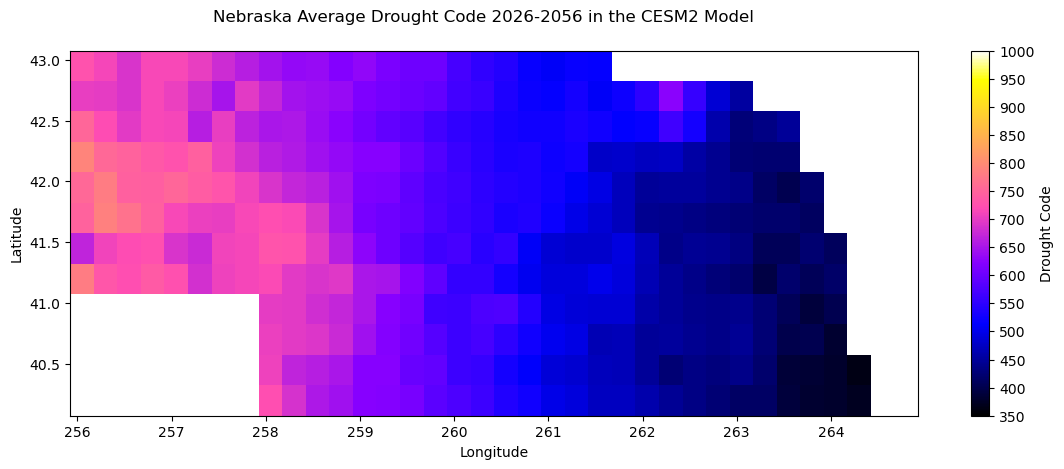

This took us about 0:00:00.128207


In [49]:
#INSET PLOT
process = input(f"Which model do you want to process? ")
series = input(f'For which time series? ')
filepathmath = f'/mnt/nrdstor/dixon/mudby97/Nebraska_Full_{series}_{process}_DC.nc'    #Nebraska_Full_{mode}_{process}_DC.nc'
try:
    tosum = xr.open_dataset(filepathmath)
    #print(f"We opened {process} as {tosum}")
except Exception as eeeee:
    print(f'{eeeee}')

start_average = time.perf_counter()    
averagedata = tosum.mean(dim = 'time')
averagetimer = timedelta(seconds=time.perf_counter() - start_average)
print(f'This took us about {averagetimer}')
print(averagedata)
list(averagedata.data_vars)

states = remy.defined_regions.natural_earth_v5_0_0.us_states_10  #DONT TOUCH! THE STATES_50 DOESNT WORK AND WILL BREAK IT 
mask = states.mask(averagedata)
neb_idx = states.names.index('Nebraska')
nebraska_masked = averagedata.where(mask == neb_idx)

start_ploat = time.perf_counter()
im = nebraska_masked['tasmax'].plot(figsize=(11.5,4.74), cmap='gnuplot2', robust=False, add_colorbar=False, vmin=350, vmax=1000)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.suptitle(f'Nebraska Average Drought Code 2026-2056 in the {process} Model', x=0.425)

plt.colorbar(im, label='Drought Code', orientation='vertical', ticks=[350,400,450,500,550,600,650,700,750,800,850,900,950,1000])

plt.tight_layout()
#plt.savefig(f"Nebraska_Avg_SSP585_{process}.png", dpi=600, bbox_inches='tight')
plt.show()
plottimer = timedelta(seconds=time.perf_counter() - start_ploat)
print(f'This took us about {plottimer}')

Which model do you want to process? GFDL-ESM4
[Errno 2] No such file or directory: '/mnt/nrdstor/dixon/mudby97/Nebraska_Lincoln_Full_SSP585_GFDL-ESM4_DC.nc'
We opened <xarray.DataArray 'tasmax' (time: 7149, lat: 12, lon: 36)> Size: 12MB
[3088368 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
  * time     (time) datetime64[ns] 57kB 1984-04-01 1984-04-02 ... 2003-10-31
Attributes:
    units:         celsius
    cell_methods:  time: mean
This took us about 0:00:00.057858
<xarray.DataArray 'tasmax' (lat: 12, lon: 36)> Size: 2kB
array([[725.5895 , 727.8914 , 691.57306, 652.73224, 632.8915 , 636.59155,
        638.9524 , 628.2199 , 635.58026, 608.08826, 578.1455 , 562.398  ,
        546.6177 , 550.23206, 541.50165, 524.3196 , 509.29413, 500.55872,
        474.3226 , 462.24756, 432.838  , 429.0229 , 417.3231 , 419.0875 ,
        410.86676, 405.7

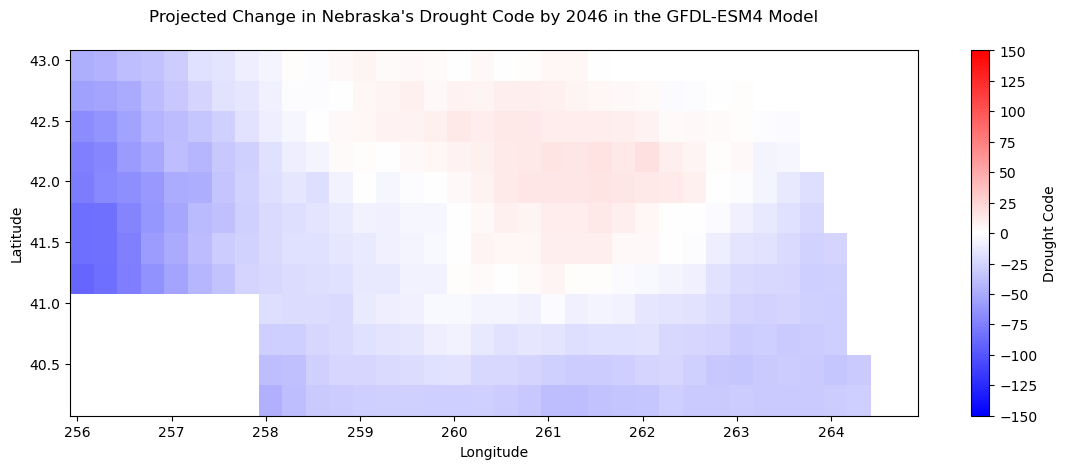

This took us about 0:00:00.899052


In [92]:
#DIFFERENCE PLOT
process = input(f"Which model do you want to process? ")
try:
    future = xr.open_dataset(f'/mnt/nrdstor/dixon/mudby97/Nebraska_Lincoln_Full_SSP585_{process}_DC.nc')
    print(f"We opened {future['tasmax']}")
except Exception as eeeee:
    print(f'{eeeee}')
    
try:
    past = xr.open_dataset(f'/mnt/nrdstor/dixon/mudby97/Nebraska_Lincoln_Full_Historical_{process}_DC.nc')
    print(f"We opened {past['tasmax']}")
except Exception as eeeeeee:
    print(f'{eeeeeee}')

start_average = time.perf_counter() #START TIMER
averagefuture = future.mean(dim = 'time') # AVERAGE SSP585 DATA
averagepast = past.mean(dim = 'time') #AVERAGE HISTORICAL DATA
finaldata = averagefuture - averagepast #SUBTRACT HIST FROM SSP TO GET AVG CHG
averagetimer = timedelta(seconds=time.perf_counter() - start_average) #STOP TIMER
print(f'This took us about {averagetimer}') #REPORT OP TIME
print(averagefuture['tasmax'])
print(averagepast['tasmax'])
print(finaldata['tasmax']) #PREVIEW DATA

states = remy.defined_regions.natural_earth_v5_0_0.us_states_10  #DONT TOUCH! THE STATES_50 DOESNT WORK AND WILL BREAK IT 
mask = states.mask(finaldata)
neb_idx = states.names.index('Nebraska')
nebraska_masked = finaldata.where(mask == neb_idx)

start_ploat = time.perf_counter()
im = nebraska_masked['tasmax'].plot(figsize=(11.5,4.74), cmap='bwr', add_colorbar=False, vmin=-150, vmax=150)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.suptitle(f"Projected Change in Nebraska's Drought Code by 2046 in the {process} Model", x=0.425)

plt.colorbar(im, label='Drought Code', orientation='vertical', ticks=[-150,-125,-100,-75,-50,-25,0,25,50,75,100,125,150])

plt.tight_layout()
plt.savefig(f"Nebraska_Avg_Diff_{process}.png", dpi=600, bbox_inches='tight')
plt.show()
plottimer = timedelta(seconds=time.perf_counter() - start_ploat)
print(f'This took us about {plottimer}')